# Portfolio Factor Exploration

This notebook generates a large universe of factor portfolio combinations across the `all`, `top500`, and `top300` universes, applies multiple transaction-cost scenarios, ranks the results, exports Excel workbooks, and saves top-portfolio graphs for each universe/cost setting.

It does not reimplement the backtest math in Python. Python creates the portfolio sweep and plots the results; the actual portfolio returns come from `scripts/notebook-backtest-runner.mjs`, which calls the same local `src/server/backtest-engine.js` oracle used for website correctness checks.

Key outputs are written to `notebooks/portfolio_sweep_output/`:

- CSV summaries for VW and EW results.
- A combined EW/VW comparison CSV.
- A master Excel workbook with all results and top-by-setting sheets.
- One Excel workbook per universe/transaction-cost setting.
- PNG charts for the top portfolio in each setting.


In [11]:
from pathlib import Path
import itertools
import json
import os
import random
import re
import subprocess
import time

REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "scripts" / "notebook-backtest-runner.mjs").exists():
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / "scripts" / "notebook-backtest-runner.mjs").exists():
    raise FileNotFoundError("Run this notebook from inside factorboosting.github.io.")

os.environ.setdefault("XDG_CACHE_HOME", str(REPO_ROOT / ".cache"))
os.environ.setdefault("MPLCONFIGDIR", str(REPO_ROOT / ".matplotlib-cache"))
Path(os.environ["XDG_CACHE_HOME"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

OUTPUT_DIR = REPO_ROOT / "notebooks" / "portfolio_sweep_output"
EXCEL_DIR = OUTPUT_DIR / "setting_excels"
CHART_DIR = OUTPUT_DIR / "top_setting_charts"
for folder in [OUTPUT_DIR, EXCEL_DIR, CHART_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#e5e7eb",
    "axes.labelcolor": "#475569",
    "axes.titlecolor": "#0f172a",
    "xtick.color": "#64748b",
    "ytick.color": "#64748b",
    "font.size": 10,
    "axes.grid": True,
    "grid.color": "#f1f5f9",
    "grid.linewidth": 1,
})

print(f"Repo root: {REPO_ROOT}")
print(f"Outputs:   {OUTPUT_DIR}")


Repo root: /Users/samyak/Documents/GitHub/factorboosting.github.io
Outputs:   /Users/samyak/Documents/GitHub/factorboosting.github.io/notebooks/portfolio_sweep_output


In [12]:
# Large research sweep controls.
# Full available history starts at 2003-10.
START_MONTH = "2003-10"
END_MONTH = "2026-05"
UNIVERSES = ["all", "top500", "top300"]
TRANSACTION_COST_BPS = [0, 10, 20, 50, 100]
ACTIVE_BENCHMARK_ID = "nifty500"

# Large default: enough random draws to discover robust patterns, while still being editable.
# Specs = base portfolios * len(UNIVERSES) * len(TRANSACTION_COST_BPS).
RANDOM_SEED = 42
N_RANDOM_LONG_ONLY = 500
N_RANDOM_LONG_SHORT = 1000
MIN_FACTORS_PER_RANDOM_PORTFOLIO = 1
MAX_FACTORS_PER_RANDOM_PORTFOLIO = 3
RANDOM_SIZE_BUCKET_PROBABILITY = 0.35

# This adds systematic grids before random portfolios.
INCLUDE_ALL_SINGLE_FACTOR_LONG_ONLY = True
INCLUDE_ALL_TWO_FACTOR_LONG_ONLY = True

# Top-setting chart controls.
TOP_SETTING_WEIGHT = "vw"
TOP_SETTING_METRIC = "sharpe_ratio"
TOP_SETTING_N = 1

FACTOR_DEFS = {
    "Size": {"labels": {"S": "Small", "B": "Big"}, "preferred": ("S", "B")},
    "Book-to-Market": {"labels": {"V": "Value", "N": "Neutral", "G": "Growth"}, "preferred": ("V", "G")},
    "Profitability": {"labels": {"R": "Robust", "N": "Neutral", "W": "Weak"}, "preferred": ("R", "W")},
    "Investment": {"labels": {"C": "Conservative", "N": "Neutral", "A": "Aggressive"}, "preferred": ("C", "A")},
    "Momentum": {"labels": {"W": "Winner", "N": "Neutral", "L": "Loser"}, "preferred": ("W", "L")},
    "Asset Turnover": {"labels": {"H": "High", "N": "Neutral", "L": "Low"}, "preferred": ("H", "L")},
    "Sales Growth": {"labels": {"H": "High", "N": "Neutral", "L": "Low"}, "preferred": ("H", "L")},
    "Accruals": {"labels": {"C": "Conservative", "N": "Neutral", "A": "Aggressive"}, "preferred": ("C", "A")},
    "Volatility": {"labels": {"L": "Low", "N": "Neutral", "H": "High"}, "preferred": ("L", "H")},
    "Short-Term Reversal": {"labels": {"L": "Loser", "N": "Neutral", "H": "Winner"}, "preferred": ("L", "H")},
}

FACTOR_ORDER = list(FACTOR_DEFS)


In [13]:
def copy_filters(filters):
    return {factor: list(labels) for factor, labels in (filters or {}).items() if labels}


def filters_to_text(filters):
    filters = copy_filters(filters)
    if not filters:
        return "All"
    pieces = []
    for factor in FACTOR_ORDER:
        if factor in filters:
            pieces.append(f"{factor}={''.join(filters[factor])}")
    for factor in sorted(set(filters) - set(FACTOR_ORDER)):
        pieces.append(f"{factor}={''.join(filters[factor])}")
    return " | ".join(pieces)


def filters_signature(filters):
    return json.dumps(copy_filters(filters), sort_keys=True, separators=(",", ":"))


def factor_tags(long_filters, short_filters=None):
    tags = set(copy_filters(long_filters))
    tags.update(copy_filters(short_filters))
    return sorted(tags, key=lambda item: FACTOR_ORDER.index(item) if item in FACTOR_ORDER else 999)


def make_base_portfolio(name, strategy, long_filters, short_filters=None, source="known"):
    long_filters = copy_filters(long_filters)
    short_filters = copy_filters(short_filters)
    key = "|".join([
        strategy,
        filters_signature(long_filters),
        filters_signature(short_filters),
    ])
    return {
        "baseId": key,
        "name": name,
        "source": source,
        "factorLabel": ", ".join(factor_tags(long_filters, short_filters)) or "All",
        "tags": factor_tags(long_filters, short_filters),
        "config": {
            "strategy": strategy,
            "longFilters": long_filters,
            "shortFilters": short_filters,
        },
    }


def build_known_portfolios():
    p = []

    # Long-only building blocks and familiar tilts.
    p.extend([
        make_base_portfolio("All stocks", "long_only", {}, source="known-long-only"),
        make_base_portfolio("Small caps", "long_only", {"Size": ["S"]}, source="known-long-only"),
        make_base_portfolio("Big caps", "long_only", {"Size": ["B"]}, source="known-long-only"),
        make_base_portfolio("Value", "long_only", {"Book-to-Market": ["V"]}, source="known-long-only"),
        make_base_portfolio("Growth", "long_only", {"Book-to-Market": ["G"]}, source="known-long-only"),
        make_base_portfolio("Momentum winners", "long_only", {"Momentum": ["W"]}, source="known-long-only"),
        make_base_portfolio("Momentum losers", "long_only", {"Momentum": ["L"]}, source="known-long-only"),
        make_base_portfolio("Robust profitability", "long_only", {"Profitability": ["R"]}, source="known-long-only"),
        make_base_portfolio("Weak profitability", "long_only", {"Profitability": ["W"]}, source="known-long-only"),
        make_base_portfolio("Conservative investment", "long_only", {"Investment": ["C"]}, source="known-long-only"),
        make_base_portfolio("Aggressive investment", "long_only", {"Investment": ["A"]}, source="known-long-only"),
        make_base_portfolio("Low volatility", "long_only", {"Volatility": ["L"]}, source="known-long-only"),
        make_base_portfolio("High volatility", "long_only", {"Volatility": ["H"]}, source="known-long-only"),
        make_base_portfolio("Small value", "long_only", {"Size": ["S"], "Book-to-Market": ["V"]}, source="known-combo"),
        make_base_portfolio("Small momentum winners", "long_only", {"Size": ["S"], "Momentum": ["W"]}, source="known-combo"),
        make_base_portfolio("Value momentum", "long_only", {"Book-to-Market": ["V"], "Momentum": ["W"]}, source="known-combo"),
        make_base_portfolio("Quality momentum", "long_only", {"Profitability": ["R"], "Momentum": ["W"]}, source="known-combo"),
        make_base_portfolio("Quality value", "long_only", {"Profitability": ["R"], "Book-to-Market": ["V"]}, source="known-combo"),
        make_base_portfolio("Conservative value", "long_only", {"Investment": ["C"], "Book-to-Market": ["V"]}, source="known-combo"),
        make_base_portfolio("Low-vol quality", "long_only", {"Volatility": ["L"], "Profitability": ["R"]}, source="known-combo"),
        make_base_portfolio("Small quality value", "long_only", {"Size": ["S"], "Profitability": ["R"], "Book-to-Market": ["V"]}, source="known-combo"),
        make_base_portfolio("Small value winners", "long_only", {"Size": ["S"], "Book-to-Market": ["V"], "Momentum": ["W"]}, source="known-combo"),
        make_base_portfolio("Quality value winners", "long_only", {"Profitability": ["R"], "Book-to-Market": ["V"], "Momentum": ["W"]}, source="known-combo"),
        make_base_portfolio("Conservative quality value", "long_only", {"Investment": ["C"], "Profitability": ["R"], "Book-to-Market": ["V"]}, source="known-combo"),
        make_base_portfolio("High asset-turnover sales-growth", "long_only", {"Asset Turnover": ["H"], "Sales Growth": ["H"]}, source="known-combo"),
        make_base_portfolio("Conservative accrual momentum", "long_only", {"Accruals": ["C"], "Momentum": ["W"]}, source="known-combo"),
        make_base_portfolio("Reversal losers plus low vol", "long_only", {"Short-Term Reversal": ["L"], "Volatility": ["L"]}, source="known-combo"),
    ])

    # Classic spread portfolios and economically motivated multi-factor spreads.
    spreads = [
        ("SMB small-minus-big", {"Size": ["S"]}, {"Size": ["B"]}),
        ("HML value-minus-growth", {"Book-to-Market": ["V"]}, {"Book-to-Market": ["G"]}),
        ("MOM winner-minus-loser", {"Momentum": ["W"]}, {"Momentum": ["L"]}),
        ("RMW robust-minus-weak", {"Profitability": ["R"]}, {"Profitability": ["W"]}),
        ("CMA conservative-minus-aggressive", {"Investment": ["C"]}, {"Investment": ["A"]}),
        ("Asset turnover high-minus-low", {"Asset Turnover": ["H"]}, {"Asset Turnover": ["L"]}),
        ("Sales growth high-minus-low", {"Sales Growth": ["H"]}, {"Sales Growth": ["L"]}),
        ("Accrual conservative-minus-aggressive", {"Accruals": ["C"]}, {"Accruals": ["A"]}),
        ("Low-vol-minus-high-vol", {"Volatility": ["L"]}, {"Volatility": ["H"]}),
        ("Short-term reversal loser-minus-winner", {"Short-Term Reversal": ["L"]}, {"Short-Term Reversal": ["H"]}),
        ("Quality momentum spread", {"Profitability": ["R"], "Momentum": ["W"]}, {"Profitability": ["W"], "Momentum": ["L"]}),
        ("Quality value spread", {"Profitability": ["R"], "Book-to-Market": ["V"]}, {"Profitability": ["W"], "Book-to-Market": ["G"]}),
        ("Conservative value spread", {"Investment": ["C"], "Book-to-Market": ["V"]}, {"Investment": ["A"], "Book-to-Market": ["G"]}),
        ("Small value winners vs big growth losers", {"Size": ["S"], "Book-to-Market": ["V"], "Momentum": ["W"]}, {"Size": ["B"], "Book-to-Market": ["G"], "Momentum": ["L"]}),
        ("Low-vol quality spread", {"Volatility": ["L"], "Profitability": ["R"]}, {"Volatility": ["H"], "Profitability": ["W"]}),
        ("Efficient growth spread", {"Asset Turnover": ["H"], "Sales Growth": ["H"]}, {"Asset Turnover": ["L"], "Sales Growth": ["L"]}),
    ]
    for name, long_filters, short_filters in spreads:
        p.append(make_base_portfolio(name, "long_short", long_filters, short_filters, source="known-spread"))
    return p


def build_single_factor_long_only_grid():
    portfolios = []
    for factor, meta in FACTOR_DEFS.items():
        for label, label_name in meta["labels"].items():
            portfolios.append(
                make_base_portfolio(f"{factor}: {label_name}", "long_only", {factor: [label]}, source="single-factor-grid")
            )
    return portfolios


def build_two_factor_long_only_grid():
    portfolios = []
    for f1, f2 in itertools.combinations(FACTOR_ORDER, 2):
        for l1, l2 in itertools.product(FACTOR_DEFS[f1]["labels"], FACTOR_DEFS[f2]["labels"]):
            name = f"{f1} {l1} + {f2} {l2}"
            portfolios.append(make_base_portfolio(name, "long_only", {f1: [l1], f2: [l2]}, source="two-factor-grid"))
    return portfolios


def build_random_long_only(n, rng, min_factors=1, max_factors=3, taken=None):
    portfolios = []
    seen = set(taken or [])
    attempts = 0
    max_attempts = max(n * 80, 1000)

    while len(portfolios) < n and attempts < max_attempts:
        attempts += 1
        k = rng.randint(min_factors, max_factors)
        chosen = rng.sample(FACTOR_ORDER, k)
        filters = {factor: [rng.choice(list(FACTOR_DEFS[factor]["labels"]))] for factor in chosen}
        candidate = make_base_portfolio(
            f"Random long-only {len(portfolios) + 1:04d}: {filters_to_text(filters)}",
            "long_only",
            filters,
            source="random-long-only",
        )
        if candidate["baseId"] in seen:
            continue
        seen.add(candidate["baseId"])
        portfolios.append(candidate)

    if len(portfolios) < n:
        print(f"Warning: requested {n:,} random long-only portfolios, built {len(portfolios):,} unique portfolios.")
    return portfolios


def build_random_long_short(n, rng, min_factors=1, max_factors=3, taken=None):
    oriented = [factor for factor, meta in FACTOR_DEFS.items() if meta.get("preferred")]
    portfolios = []
    seen = set(taken or [])
    attempts = 0
    max_attempts = max(n * 80, 1000)

    while len(portfolios) < n and attempts < max_attempts:
        attempts += 1
        k = rng.randint(min_factors, max_factors)
        chosen = rng.sample(oriented, k)
        long_filters = {}
        short_filters = {}
        for factor in chosen:
            good, bad = FACTOR_DEFS[factor]["preferred"]
            long_filters[factor] = [good]
            short_filters[factor] = [bad]

        # Sometimes compare the spread inside the same size bucket instead of also making a size spread.
        if "Size" not in chosen and rng.random() < RANDOM_SIZE_BUCKET_PROBABILITY:
            size_label = rng.choice(["S", "B"])
            long_filters["Size"] = [size_label]
            short_filters["Size"] = [size_label]

        candidate = make_base_portfolio(
            f"Random spread {len(portfolios) + 1:04d}: {filters_to_text(long_filters)} vs {filters_to_text(short_filters)}",
            "long_short",
            long_filters,
            short_filters,
            source="random-long-short",
        )
        if candidate["baseId"] in seen:
            continue
        seen.add(candidate["baseId"])
        portfolios.append(candidate)

    if len(portfolios) < n:
        print(f"Warning: requested {n:,} random long-short portfolios, built {len(portfolios):,} unique portfolios.")
    return portfolios


def dedupe_base_portfolios(portfolios):
    by_id = {}
    for portfolio in portfolios:
        by_id.setdefault(portfolio["baseId"], portfolio)
    return list(by_id.values())


def build_base_portfolios():
    rng = random.Random(RANDOM_SEED)
    portfolios = []
    portfolios.extend(build_known_portfolios())
    if INCLUDE_ALL_SINGLE_FACTOR_LONG_ONLY:
        portfolios.extend(build_single_factor_long_only_grid())
    if INCLUDE_ALL_TWO_FACTOR_LONG_ONLY:
        portfolios.extend(build_two_factor_long_only_grid())

    portfolios = dedupe_base_portfolios(portfolios)
    taken = {portfolio["baseId"] for portfolio in portfolios}

    random_long_only = build_random_long_only(
        N_RANDOM_LONG_ONLY,
        rng,
        MIN_FACTORS_PER_RANDOM_PORTFOLIO,
        MAX_FACTORS_PER_RANDOM_PORTFOLIO,
        taken=taken,
    )
    portfolios.extend(random_long_only)
    taken.update(portfolio["baseId"] for portfolio in random_long_only)

    random_long_short = build_random_long_short(
        N_RANDOM_LONG_SHORT,
        rng,
        MIN_FACTORS_PER_RANDOM_PORTFOLIO,
        MAX_FACTORS_PER_RANDOM_PORTFOLIO,
        taken=taken,
    )
    portfolios.extend(random_long_short)
    return portfolios


def transaction_cost_payload(bps):
    bps = float(bps)
    if bps <= 0:
        return {"mode": "none", "bps": 0}
    return {"mode": "bps", "bps": bps}


def expand_specs(base_portfolios, universes=UNIVERSES, costs=TRANSACTION_COST_BPS):
    specs = []
    for base_index, base in enumerate(base_portfolios):
        for universe in universes:
            for bps in costs:
                spec_id = f"{base_index:04d}-{universe}-tc{int(bps)}"
                specs.append({
                    **base,
                    "specId": spec_id,
                    "universe": universe,
                    "startMonth": START_MONTH,
                    "endMonth": END_MONTH,
                    "activeBenchmarkId": ACTIVE_BENCHMARK_ID,
                    "transactionCost": transaction_cost_payload(bps),
                })
    return specs


In [14]:
base_portfolios = build_base_portfolios()
sweep_specs = expand_specs(base_portfolios)

print(f"Base portfolios: {len(base_portfolios):,}")
print(f"Sweep specs:      {len(sweep_specs):,}")
print(f"Universes:        {UNIVERSES}")
print(f"TC bps:           {TRANSACTION_COST_BPS}")
print(f"Random seed:      {RANDOM_SEED}")
print(f"Date window:      {START_MONTH} -> {END_MONTH}")
print("Note: full runs can take a while. Lower the random counts while editing plotting/export code.")

preview = pd.DataFrame([
    {
        "name": p["name"],
        "source": p["source"],
        "strategy": p["config"]["strategy"],
        "long": filters_to_text(p["config"]["longFilters"]),
        "short": filters_to_text(p["config"]["shortFilters"]),
    }
    for p in base_portfolios[:25]
])
display(preview)


Base portfolios: 1,345
Sweep specs:      20,175
Universes:        ['all', 'top500', 'top300']
TC bps:           [0, 10, 20, 50, 100]
Random seed:      42
Date window:      2003-10 -> 2026-05
Note: full runs can take a while. Lower the random counts while editing plotting/export code.


,name,source,strategy,long,short
0,All stocks,known-long-only,long_only,All,All
1,Small caps,known-long-only,long_only,Size=S,All
2,Big caps,known-long-only,long_only,Size=B,All
3,Value,known-long-only,long_only,Book-to-Market=V,All
4,Growth,known-long-only,long_only,Book-to-Market=G,All
5,Momentum winners,known-long-only,long_only,Momentum=W,All
6,Momentum losers,known-long-only,long_only,Momentum=L,All
7,Robust profitability,known-long-only,long_only,Profitability=R,All
8,Weak profitability,known-long-only,long_only,Profitability=W,All
9,Conservative investment,known-long-only,long_only,Investment=C,All


In [15]:
def run_backtest_sweep(specs, include_benchmarks=True):
    runner = REPO_ROOT / "scripts" / "notebook-backtest-runner.mjs"
    payload = {"specs": specs, "includeBenchmarkSeries": include_benchmarks}
    started = time.time()
    completed = subprocess.run(
        ["node", str(runner)],
        cwd=REPO_ROOT,
        input=json.dumps(payload),
        capture_output=True,
        text=True,
    )
    elapsed = time.time() - started
    if completed.returncode != 0:
        raise RuntimeError(completed.stderr[-4000:] or completed.stdout[-4000:])

    response = json.loads(completed.stdout)
    print(f"Backtested {len(response['results']):,} portfolios in {elapsed:,.1f}s.")
    if response.get("errors"):
        print(f"Errors: {len(response['errors'])}")
        display(pd.DataFrame(response["errors"]).head(20))
    return response


def tc_bps(item):
    tc = item.get("transactionCost") or {}
    if tc.get("mode") != "bps":
        return 0.0
    return float(tc.get("bps") or 0)


def summarize_results(results, weight="vw"):
    rows = []
    for item in results:
        portfolio_results = item["results"]
        metrics = portfolio_results[f"{weight}_metrics"]
        config = item["config"]
        rows.append({
            "specId": item["specId"],
            "baseId": item.get("baseId"),
            "name": item["name"],
            "source": item.get("source", "custom"),
            "universe": item["universe"],
            "tc_bps": tc_bps(item),
            "weight": weight.upper(),
            "strategy": config.get("strategy"),
            "long": filters_to_text(config.get("longFilters")),
            "short": filters_to_text(config.get("shortFilters")),
            "tags": ", ".join(item.get("tags") or []),
            "avg_long_stocks": portfolio_results.get("avgLongStocks"),
            "avg_short_stocks": portfolio_results.get("avgShortStocks"),
            "last_long_stocks": portfolio_results.get("lastLongStocks"),
            "last_short_stocks": portfolio_results.get("lastShortStocks"),
            "min_long_stocks": portfolio_results.get("minLongStocks"),
            "min_short_stocks": portfolio_results.get("minShortStocks"),
            "max_long_stocks": portfolio_results.get("maxLongStocks"),
            "max_short_stocks": portfolio_results.get("maxShortStocks"),
            "avg_turnover_pct": portfolio_results.get("avgTurnover"),
            "growth_multiple": metrics.get("growth_multiple"),
            "annualized_return": metrics.get("annualized_return"),
            "annualized_volatility": metrics.get("annualized_volatility"),
            "sharpe_ratio": metrics.get("sharpe_ratio"),
            "information_ratio": metrics.get("ir"),
            "max_drawdown": metrics.get("max_drawdown"),
            "months": len(item.get("months") or []),
        })
    return pd.DataFrame(rows)


def save_summary(summary, weight):
    path = OUTPUT_DIR / f"portfolio_sweep_summary_{weight.lower()}.csv"
    summary.to_csv(path, index=False)
    print(f"Saved {path}")


In [16]:
# Set RUN_FULL_SWEEP to False while editing plotting/export code; set it True to run the full exploration.
RUN_FULL_SWEEP = True

if RUN_FULL_SWEEP:
    sweep_response = run_backtest_sweep(sweep_specs, include_benchmarks=True)
    results = sweep_response["results"]
    benchmark_lookup = sweep_response["benchmarkSeriesByKey"]
    summary_vw = summarize_results(results, weight="vw")
    summary_ew = summarize_results(results, weight="ew")
    save_summary(summary_vw, "vw")
    save_summary(summary_ew, "ew")

    print("Top VW portfolios by Sharpe:")
    display(
        summary_vw
        .sort_values(["sharpe_ratio", "annualized_return"], ascending=False)
        .head(25)
        [[
            "name", "source", "universe", "tc_bps", "strategy",
            "annualized_return", "annualized_volatility", "sharpe_ratio", "information_ratio", "max_drawdown",
            "avg_long_stocks", "avg_short_stocks", "last_long_stocks", "last_short_stocks",
            "avg_turnover_pct", "long", "short",
        ]]
    )
else:
    results = []
    benchmark_lookup = {}
    summary_vw = pd.DataFrame()
    summary_ew = pd.DataFrame()


Backtested 20,175 portfolios in 1,566.5s.
Saved /Users/samyak/Documents/GitHub/factorboosting.github.io/notebooks/portfolio_sweep_output/portfolio_sweep_summary_vw.csv
Saved /Users/samyak/Documents/GitHub/factorboosting.github.io/notebooks/portfolio_sweep_output/portfolio_sweep_summary_ew.csv
Top VW portfolios by Sharpe:


,name,source,universe,tc_bps,strategy,annualized_return,annualized_volatility,sharpe_ratio,information_ratio,max_drawdown,avg_long_stocks,avg_short_stocks,last_long_stocks,last_short_stocks,avg_turnover_pct,long,short
38,Quality value spread,known-spread,all,0.0,long_short,33.18,20.62,1.504,0.540,-31.43,50.6,58.2,51,86,46.5,Book-to-Market=V | Profitability=R,Book-to-Market=G | Profitability=W
1263,Random spread 0336: Size=S | Book-to-Market=V ...,random-long-short,all,0.0,long_short,33.18,20.62,1.504,0.540,-31.43,50.6,58.2,51,86,46.5,Size=S | Book-to-Market=V | Profitability=R,Size=S | Book-to-Market=G | Profitability=W
1030,Random spread 0103: Book-to-Market=V | Investm...,random-long-short,all,0.0,long_short,37.71,23.59,1.486,0.599,-34.71,42.7,30.0,61,47,49.1,Book-to-Market=V | Investment=C | Asset Turnov...,Book-to-Market=G | Investment=A | Asset Turnov...
1234,Random spread 0307: Size=S | Book-to-Market=V ...,random-long-short,all,0.0,long_short,37.71,23.59,1.486,0.599,-34.71,42.7,30.0,61,47,49.1,Size=S | Book-to-Market=V | Investment=C | Ass...,Size=S | Book-to-Market=G | Investment=A | Ass...
1383,Quality value spread,known-spread,all,10.0,long_short,32.47,20.62,1.477,0.521,-32.59,50.6,58.2,51,86,46.5,Book-to-Market=V | Profitability=R,Book-to-Market=G | Profitability=W
2608,Random spread 0336: Size=S | Book-to-Market=V ...,random-long-short,all,10.0,long_short,32.47,20.62,1.477,0.521,-32.59,50.6,58.2,51,86,46.5,Size=S | Book-to-Market=V | Profitability=R,Size=S | Book-to-Market=G | Profitability=W
2375,Random spread 0103: Book-to-Market=V | Investm...,random-long-short,all,10.0,long_short,36.95,23.55,1.464,0.582,-35.57,42.7,30.0,61,47,49.1,Book-to-Market=V | Investment=C | Asset Turnov...,Book-to-Market=G | Investment=A | Asset Turnov...
2579,Random spread 0307: Size=S | Book-to-Market=V ...,random-long-short,all,10.0,long_short,36.95,23.55,1.464,0.582,-35.57,42.7,30.0,61,47,49.1,Size=S | Book-to-Market=V | Investment=C | Ass...,Size=S | Book-to-Market=G | Investment=A | Ass...
2728,Quality value spread,known-spread,all,20.0,long_short,31.76,20.62,1.450,0.501,-33.73,50.6,58.2,51,86,46.5,Book-to-Market=V | Profitability=R,Book-to-Market=G | Profitability=W
3953,Random spread 0336: Size=S | Book-to-Market=V ...,random-long-short,all,20.0,long_short,31.76,20.62,1.450,0.501,-33.73,50.6,58.2,51,86,46.5,Size=S | Book-to-Market=V | Profitability=R,Size=S | Book-to-Market=G | Profitability=W


In [17]:
COLORS = ["#3b82f6", "#10b981", "#f59e0b", "#8b5cf6", "#ec4899", "#0ea5e9", "#84cc16", "#f97316", "#14b8a6", "#64748b"]
BENCH_COLOR = "#ef4444"


def style_axis(ax):
    ax.grid(True, color="#f1f5f9", linewidth=1)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#e5e7eb")
    ax.spines["bottom"].set_color("#e5e7eb")
    ax.tick_params(colors="#64748b")


def month_dates(months, include_initial=False):
    dates = pd.to_datetime([f"{month}-01" for month in months])
    if include_initial and len(dates):
        dates = pd.DatetimeIndex([dates[0] - pd.DateOffset(months=1)]).append(dates)
    return dates


def results_by_id(results):
    return {item["specId"]: item for item in results}


def select_top_results(summary, results, universe="top500", tc_bps=0, metric="sharpe_ratio", n=5, source=None):
    if summary.empty:
        return []
    frame = summary[(summary["universe"] == universe) & (summary["tc_bps"] == float(tc_bps))].copy()
    if source:
        frame = frame[frame["source"].eq(source)]
    frame = frame.sort_values([metric, "annualized_return"], ascending=False).head(n)
    lookup = results_by_id(results)
    return [lookup[spec_id] for spec_id in frame["specId"] if spec_id in lookup]


def plot_equity_curves(selected, weight="vw", benchmark=True, log_scale=False, title=None, ax=None):
    if not selected:
        raise ValueError("No selected results to plot.")
    if ax is None:
        _, ax = plt.subplots(figsize=(13, 6))

    for idx, item in enumerate(selected):
        months = item["months"]
        dates = month_dates(months, include_initial=True)
        curve = [100] + item["results"][f"{weight}_portfolio"]
        label = f"{item['name']} ({item['universe']}, {tc_bps(item):g} bps)"
        ax.plot(dates, curve, color=COLORS[idx % len(COLORS)], linewidth=2, label=label)

    run_keys = {item["runKey"] for item in selected}
    if benchmark and len(run_keys) == 1:
        bundle = benchmark_lookup.get(next(iter(run_keys)), {})
        bench_id = bundle.get("activeBenchmarkId", ACTIVE_BENCHMARK_ID)
        bench = (bundle.get("benchmarkSeries") or {}).get(bench_id)
        if bench:
            dates = month_dates(bundle["months"], include_initial=True)
            ax.plot(dates, [100] + bench["portfolio"], color=BENCH_COLOR, linewidth=2, linestyle=(0, (6, 3)), label=bench_id.upper())

    if log_scale:
        ax.set_yscale("log")
    ax.set_title(title or f"{weight.upper()} portfolio returns")
    ax.set_ylabel("Portfolio value, start = 100")
    ax.legend(loc="upper left", fontsize=8, frameon=False)
    style_axis(ax)
    return ax


def plot_drawdowns(selected, weight="vw", benchmark=True, title=None, ax=None):
    if not selected:
        raise ValueError("No selected results to plot.")
    if ax is None:
        _, ax = plt.subplots(figsize=(13, 4.5))

    for idx, item in enumerate(selected):
        dates = month_dates(item["months"])
        dd = item["results"][f"{weight}_drawdown"]
        color = COLORS[idx % len(COLORS)]
        ax.plot(dates, dd, color=color, linewidth=1.7, label=item["name"])
        ax.fill_between(dates, dd, 0, color=color, alpha=0.08)

    run_keys = {item["runKey"] for item in selected}
    if benchmark and len(run_keys) == 1:
        bundle = benchmark_lookup.get(next(iter(run_keys)), {})
        bench_id = bundle.get("activeBenchmarkId", ACTIVE_BENCHMARK_ID)
        bench = (bundle.get("benchmarkSeries") or {}).get(bench_id)
        if bench:
            dates = month_dates(bundle["months"])
            ax.plot(dates, bench["drawdown"], color=BENCH_COLOR, linewidth=1.7, linestyle=(0, (6, 3)), label=bench_id.upper())

    ax.set_title(title or f"{weight.upper()} drawdown")
    ax.set_ylabel("Drawdown (%)")
    ax.legend(loc="lower left", fontsize=8, frameon=False)
    style_axis(ax)
    return ax


def plot_leaderboard(summary, metric="sharpe_ratio", n=20, universe=None, tc_bps_value=None, title=None):
    frame = summary.copy()
    if universe is not None:
        frame = frame[frame["universe"] == universe]
    if tc_bps_value is not None:
        frame = frame[frame["tc_bps"] == float(tc_bps_value)]
    frame = frame.sort_values([metric, "annualized_return"], ascending=False).head(n)
    labels = frame["name"] + " | " + frame["universe"] + " | " + frame["tc_bps"].astype(int).astype(str) + " bps"

    _, ax = plt.subplots(figsize=(11, max(5, n * 0.32)))
    ax.barh(labels[::-1], frame[metric].iloc[::-1], color="#3b82f6", alpha=0.88)
    ax.set_title(title or f"Top {n} by {metric}")
    ax.set_xlabel(metric)
    style_axis(ax)
    return ax


def plot_tc_sensitivity(summary, metric="sharpe_ratio", universe="top500", top_n=8):
    base = summary[(summary["universe"] == universe) & (summary["tc_bps"] == 0)].copy()
    names = base.sort_values([metric, "annualized_return"], ascending=False).head(top_n)["name"].tolist()
    frame = summary[(summary["universe"] == universe) & (summary["name"].isin(names))]
    pivot = frame.pivot_table(index="tc_bps", columns="name", values=metric, aggfunc="mean").sort_index()

    _, ax = plt.subplots(figsize=(12, 5.5))
    for idx, name in enumerate(pivot.columns):
        ax.plot(pivot.index, pivot[name], marker="o", linewidth=2, color=COLORS[idx % len(COLORS)], label=name)
    ax.set_title(f"Transaction-cost sensitivity ({universe}, {metric})")
    ax.set_xlabel("Transaction cost, bps on traded portfolio value")
    ax.set_ylabel(metric)
    ax.legend(loc="best", fontsize=8, frameon=False)
    style_axis(ax)
    return ax


def plot_factor_heatmap(summary, metric="sharpe_ratio", tc_bps_value=0):
    rows = []
    frame = summary[summary["tc_bps"] == float(tc_bps_value)]
    for _, row in frame.iterrows():
        tags = [tag.strip() for tag in str(row["tags"]).split(",") if tag.strip()]
        for tag in tags or ["All"]:
            rows.append({"factor": tag, "universe": row["universe"], metric: row[metric]})
    heat = pd.DataFrame(rows).pivot_table(index="factor", columns="universe", values=metric, aggfunc="mean")
    heat = heat.reindex([factor for factor in FACTOR_ORDER if factor in heat.index] + [idx for idx in heat.index if idx not in FACTOR_ORDER])

    _, ax = plt.subplots(figsize=(7, max(4, len(heat) * 0.42)))
    image = ax.imshow(heat.values, aspect="auto", cmap="RdYlGn")
    ax.set_xticks(range(len(heat.columns)), heat.columns)
    ax.set_yticks(range(len(heat.index)), heat.index)
    ax.set_title(f"Average {metric} by factor tag ({tc_bps_value:g} bps)")
    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            value = heat.values[i, j]
            if np.isfinite(value):
                ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8, color="#0f172a")
    plt.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    return ax


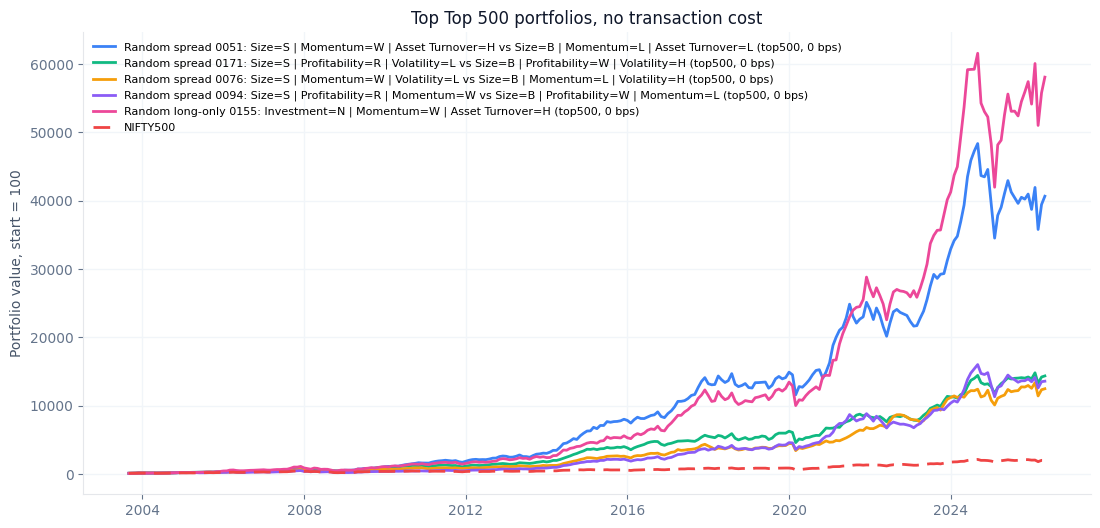

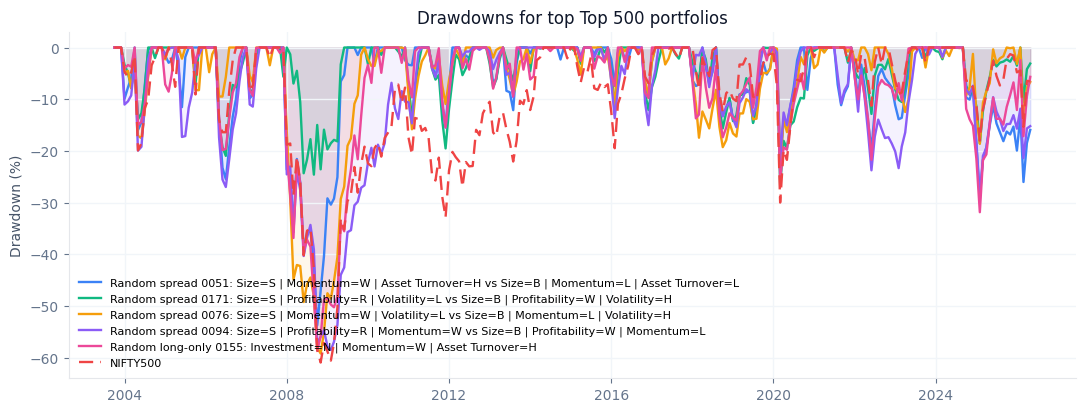

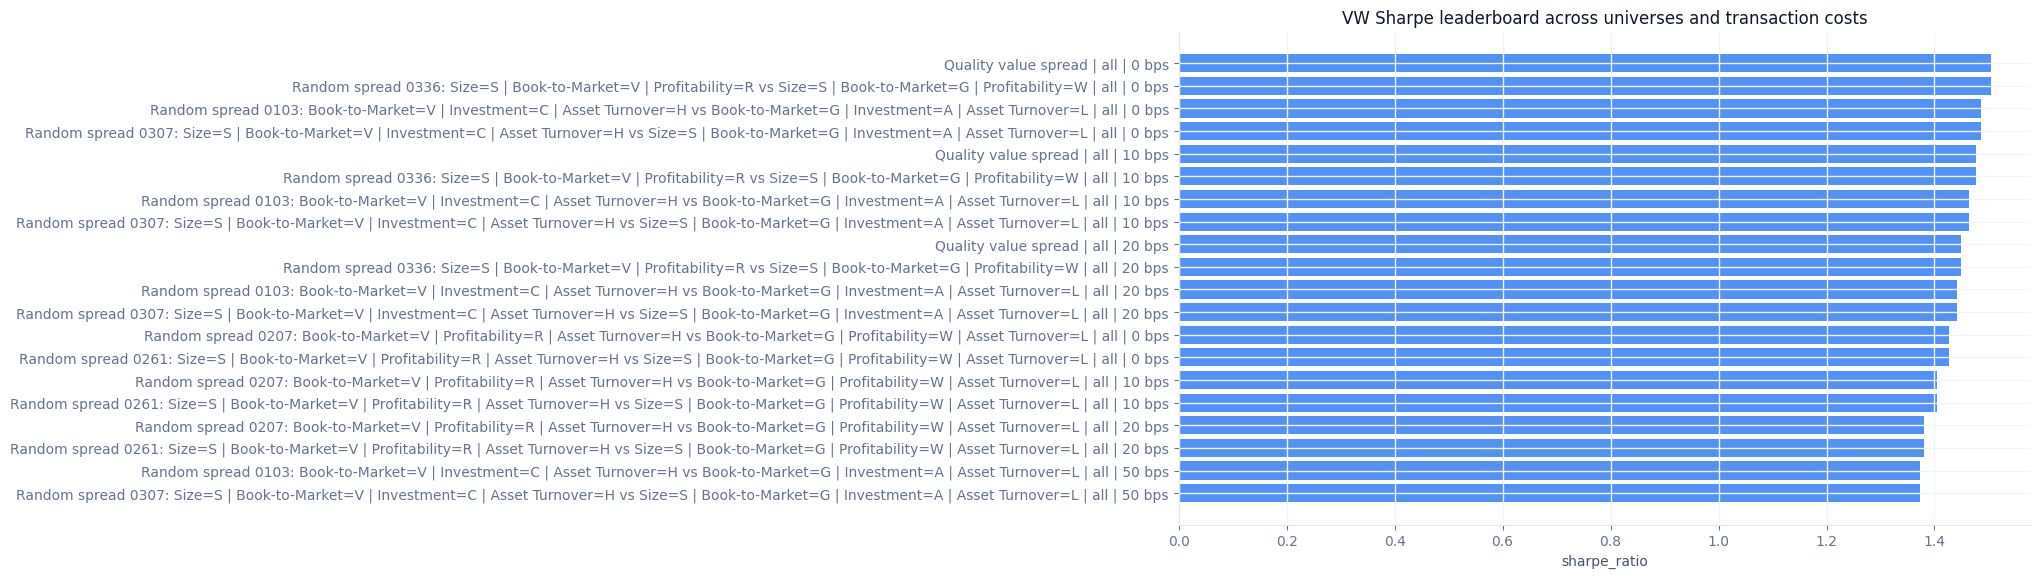

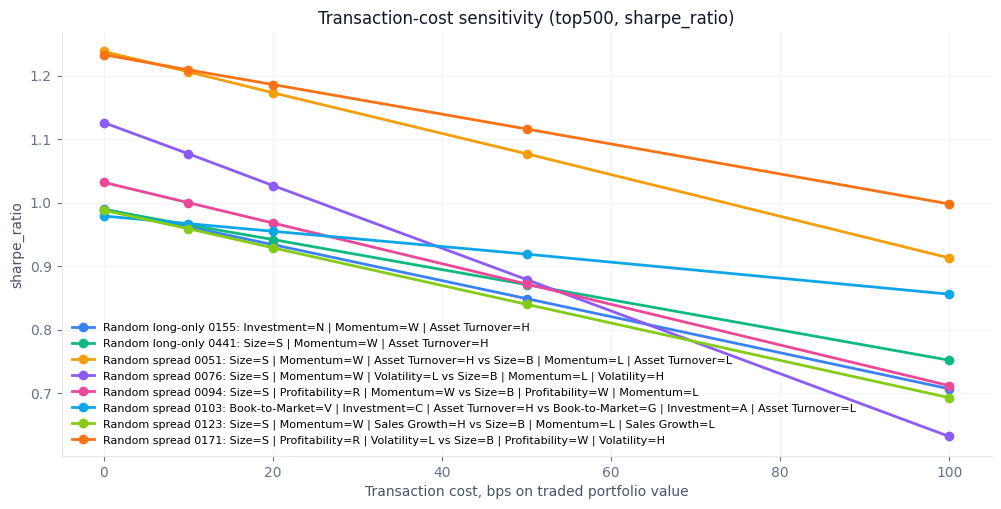

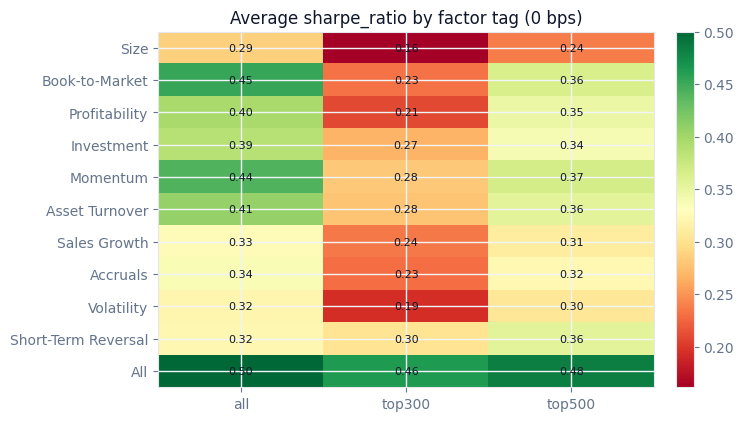

In [18]:
if not summary_vw.empty:
    top_top500_no_tc = select_top_results(summary_vw, results, universe="top500", tc_bps=0, metric="sharpe_ratio", n=5)
    plot_equity_curves(top_top500_no_tc, weight="vw", benchmark=True, log_scale=False, title="Top Top 500 portfolios, no transaction cost")
    plt.show()

    plot_drawdowns(top_top500_no_tc, weight="vw", benchmark=True, title="Drawdowns for top Top 500 portfolios")
    plt.show()

    plot_leaderboard(summary_vw, metric="sharpe_ratio", n=20, title="VW Sharpe leaderboard across universes and transaction costs")
    plt.show()

    plot_tc_sensitivity(summary_vw, metric="sharpe_ratio", universe="top500", top_n=8)
    plt.show()

    plot_factor_heatmap(summary_vw, metric="sharpe_ratio", tc_bps_value=0)
    plt.show()


In [19]:
%pip install openpyxl
def build_ew_vw_comparison(summary_vw, summary_ew):
    identity_cols = [
        "specId", "baseId", "name", "source", "universe", "tc_bps", "strategy", "long", "short", "tags",
        "avg_long_stocks", "avg_short_stocks", "last_long_stocks", "last_short_stocks",
        "min_long_stocks", "min_short_stocks", "max_long_stocks", "max_short_stocks", "avg_turnover_pct", "months",
    ]
    vw_cols = identity_cols + [
        "growth_multiple", "annualized_return", "annualized_volatility", "sharpe_ratio", "information_ratio", "max_drawdown"
    ]
    ew_cols = [
        "specId", "growth_multiple", "annualized_return", "annualized_volatility", "sharpe_ratio", "information_ratio", "max_drawdown"
    ]
    comparison = (
        summary_vw[vw_cols]
        .rename(columns={
            "growth_multiple": "vw_growth",
            "annualized_return": "vw_ann_return",
            "annualized_volatility": "vw_ann_volatility",
            "sharpe_ratio": "vw_sharpe",
            "information_ratio": "vw_information_ratio",
            "max_drawdown": "vw_max_dd",
        })
        .merge(
            summary_ew[ew_cols]
            .rename(columns={
                "growth_multiple": "ew_growth",
                "annualized_return": "ew_ann_return",
                "annualized_volatility": "ew_ann_volatility",
                "sharpe_ratio": "ew_sharpe",
                "information_ratio": "ew_information_ratio",
                "max_drawdown": "ew_max_dd",
            }),
            on="specId",
            how="left",
        )
        .sort_values(["vw_sharpe", "vw_ann_return"], ascending=False)
    )
    return comparison


def build_top_by_setting(summary, metric="sharpe_ratio", n=1):
    if summary.empty:
        return pd.DataFrame()
    rows = []
    for universe in UNIVERSES:
        for bps in TRANSACTION_COST_BPS:
            frame = summary[(summary["universe"] == universe) & (summary["tc_bps"] == float(bps))]
            frame = frame.sort_values([metric, "annualized_return"], ascending=False).head(n).copy()
            if frame.empty:
                continue
            frame.insert(0, "rank_within_setting", range(1, len(frame) + 1))
            rows.append(frame)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


def safe_filename(value):
    value = str(value).strip().lower()
    value = re.sub(r"[^a-z0-9._-]+", "_", value)
    return value.strip("_") or "file"


def write_excel_workbook(path, sheets):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with pd.ExcelWriter(path, engine="openpyxl") as writer:
        for sheet_name, frame in sheets.items():
            if frame is None or frame.empty:
                continue
            frame.to_excel(writer, sheet_name=sheet_name[:31], index=False)

    from openpyxl import load_workbook
    from openpyxl.styles import Alignment, Font, PatternFill

    wb = load_workbook(path)
    header_fill = PatternFill("solid", fgColor="E8F0FE")
    wide_headers = {"name", "long", "short", "tags"}
    medium_headers = {"specId", "baseId", "source", "universe", "strategy"}

    for ws in wb.worksheets:
        ws.freeze_panes = "A2"
        ws.auto_filter.ref = ws.dimensions
        headers = [cell.value for cell in ws[1]]
        for cell in ws[1]:
            cell.font = Font(bold=True)
            cell.fill = header_fill
            cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        for col_idx, header in enumerate(headers, start=1):
            letter = ws.cell(row=1, column=col_idx).column_letter
            if header in wide_headers:
                ws.column_dimensions[letter].width = 46 if header != "name" else 58
            elif header in medium_headers:
                ws.column_dimensions[letter].width = 22
            else:
                ws.column_dimensions[letter].width = 14
            wrap = header in wide_headers
            for cell in ws.iter_cols(min_col=col_idx, max_col=col_idx, min_row=2, max_row=ws.max_row):
                for item in cell:
                    item.alignment = Alignment(vertical="top", wrap_text=wrap)
    wb.save(path)
    return path


def export_master_excel(summary_vw, summary_ew, comparison, top_vw, top_ew):
    path = OUTPUT_DIR / "portfolio_sweep_all_results.xlsx"
    write_excel_workbook(path, {
        "vw_summary": summary_vw.sort_values(["sharpe_ratio", "annualized_return"], ascending=False),
        "ew_summary": summary_ew.sort_values(["sharpe_ratio", "annualized_return"], ascending=False),
        "ew_vw_comparison": comparison,
        "top_vw_by_setting": top_vw,
        "top_ew_by_setting": top_ew,
    })
    print(f"Saved master Excel: {path}")
    return path


def export_setting_excels(comparison, top_n=100):
    files = []
    for universe in UNIVERSES:
        for bps in TRANSACTION_COST_BPS:
            frame = comparison[(comparison["universe"] == universe) & (comparison["tc_bps"] == float(bps))].copy()
            if frame.empty:
                continue
            frame_vw = frame.sort_values(["vw_sharpe", "vw_ann_return"], ascending=False)
            frame_ew = frame.sort_values(["ew_sharpe", "ew_ann_return"], ascending=False)
            path = EXCEL_DIR / f"portfolio_sweep_{safe_filename(universe)}_tc{int(bps)}bps.xlsx"
            write_excel_workbook(path, {
                "all_sorted_by_vw": frame_vw,
                "top_vw": frame_vw.head(top_n),
                "top_ew": frame_ew.head(top_n),
            })
            files.append(path)
    print(f"Saved {len(files):,} setting Excel files in {EXCEL_DIR}")
    return files


def save_top_setting_charts(summary, results, weight="vw", metric="sharpe_ratio", top_n=1):
    CHART_DIR.mkdir(parents=True, exist_ok=True)
    manifest_rows = []
    lookup = results_by_id(results)

    for universe in UNIVERSES:
        for bps in TRANSACTION_COST_BPS:
            frame = summary[(summary["universe"] == universe) & (summary["tc_bps"] == float(bps))].copy()
            frame = frame.sort_values([metric, "annualized_return"], ascending=False).head(top_n)
            if frame.empty:
                continue
            selected = [lookup[spec_id] for spec_id in frame["specId"] if spec_id in lookup]
            if not selected:
                continue

            fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
            title = f"Top {weight.upper()} portfolio: {universe}, {int(bps)} bps, ranked by {metric}"
            plot_equity_curves(selected, weight=weight, benchmark=True, log_scale=False, title=title, ax=axes[0])
            plot_drawdowns(selected, weight=weight, benchmark=True, title="Drawdown", ax=axes[1])
            plt.tight_layout()

            file_path = CHART_DIR / f"top_{weight}_{safe_filename(universe)}_tc{int(bps)}bps.png"
            fig.savefig(file_path, dpi=160, bbox_inches="tight")
            plt.close(fig)

            for rank, (_, row) in enumerate(frame.iterrows(), start=1):
                manifest_rows.append({
                    "rank": rank,
                    "universe": universe,
                    "tc_bps": float(bps),
                    "weight": weight.upper(),
                    "metric": metric,
                    "chart_path": str(file_path),
                    **row.to_dict(),
                })

    manifest = pd.DataFrame(manifest_rows)
    manifest_path = OUTPUT_DIR / f"top_{weight}_setting_chart_manifest.csv"
    manifest.to_csv(manifest_path, index=False)
    print(f"Saved top-setting charts in {CHART_DIR}")
    print(f"Saved chart manifest: {manifest_path}")
    return manifest


if not summary_vw.empty:
    comparison = build_ew_vw_comparison(summary_vw, summary_ew)
    comparison_path = OUTPUT_DIR / "portfolio_sweep_ew_vw_comparison.csv"
    comparison.to_csv(comparison_path, index=False)
    print(f"Saved {comparison_path}")

    top_vw_by_setting = build_top_by_setting(summary_vw, metric=TOP_SETTING_METRIC, n=TOP_SETTING_N)
    top_ew_by_setting = build_top_by_setting(summary_ew, metric=TOP_SETTING_METRIC, n=TOP_SETTING_N)

    display(comparison.head(25))
    print("Top VW portfolio for each universe/cost setting:")
    display(top_vw_by_setting[[
        "rank_within_setting", "universe", "tc_bps", "name", "source", "strategy",
        "annualized_return", "sharpe_ratio", "max_drawdown", "avg_long_stocks", "avg_short_stocks", "long", "short",
    ]])

    master_excel_path = export_master_excel(summary_vw, summary_ew, comparison, top_vw_by_setting, top_ew_by_setting)
    setting_excel_files = export_setting_excels(comparison, top_n=100)
    top_setting_chart_manifest = save_top_setting_charts(
        summary_vw if TOP_SETTING_WEIGHT == "vw" else summary_ew,
        results,
        weight=TOP_SETTING_WEIGHT,
        metric=TOP_SETTING_METRIC,
        top_n=TOP_SETTING_N,
    )



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Saved /Users/samyak/Documents/GitHub/factorboosting.github.io/notebooks/portfolio_sweep_output/portfolio_sweep_ew_vw_comparison.csv


,specId,baseId,name,source,universe,tc_bps,strategy,long,short,tags,avg_long_stocks,avg_short_stocks,last_long_stocks,last_short_stocks,min_long_stocks,min_short_stocks,max_long_stocks,max_short_stocks,avg_turnover_pct,months,vw_growth,vw_ann_return,vw_ann_volatility,vw_sharpe,vw_information_ratio,vw_max_dd,ew_growth,ew_ann_return,ew_ann_volatility,ew_sharpe,ew_information_ratio,ew_max_dd
38,0038-all-tc0,"long_short|{""Book-to-Market"":[""V""],""Profitabil...",Quality value spread,known-spread,all,0.0,long_short,Book-to-Market=V | Profitability=R,Book-to-Market=G | Profitability=W,"Book-to-Market, Profitability",50.6,58.2,51,86,14,10,89,97,46.5,272,661.62,33.18,20.62,1.504,0.540,-31.43,474.08,31.24,17.03,1.696,0.484,-19.60
1263,1263-all-tc0,"long_short|{""Book-to-Market"":[""V""],""Profitabil...",Random spread 0336: Size=S | Book-to-Market=V ...,random-long-short,all,0.0,long_short,Size=S | Book-to-Market=V | Profitability=R,Size=S | Book-to-Market=G | Profitability=W,"Size, Book-to-Market, Profitability",50.6,58.2,51,86,14,10,89,97,46.5,272,661.62,33.18,20.62,1.504,0.540,-31.43,474.08,31.24,17.03,1.696,0.484,-19.60
1030,1030-all-tc0,"long_short|{""Asset Turnover"":[""H""],""Book-to-Ma...",Random spread 0103: Book-to-Market=V | Investm...,random-long-short,all,0.0,long_short,Book-to-Market=V | Investment=C | Asset Turnov...,Book-to-Market=G | Investment=A | Asset Turnov...,"Book-to-Market, Investment, Asset Turnover",42.7,30.0,61,47,0,0,83,54,49.1,272,1412.06,37.71,23.59,1.486,0.599,-34.71,120.76,23.55,19.26,1.201,0.234,-36.67
1234,1234-all-tc0,"long_short|{""Asset Turnover"":[""H""],""Book-to-Ma...",Random spread 0307: Size=S | Book-to-Market=V ...,random-long-short,all,0.0,long_short,Size=S | Book-to-Market=V | Investment=C | Ass...,Size=S | Book-to-Market=G | Investment=A | Ass...,"Size, Book-to-Market, Investment, Asset Turnover",42.7,30.0,61,47,0,0,83,54,49.1,272,1412.06,37.71,23.59,1.486,0.599,-34.71,120.76,23.55,19.26,1.201,0.234,-36.67
1383,0038-all-tc10,"long_short|{""Book-to-Market"":[""V""],""Profitabil...",Quality value spread,known-spread,all,10.0,long_short,Book-to-Market=V | Profitability=R,Book-to-Market=G | Profitability=W,"Book-to-Market, Profitability",50.6,58.2,51,86,14,10,89,97,46.5,272,585.75,32.47,20.62,1.477,0.521,-32.59,418.45,30.52,17.03,1.663,0.463,-19.93
2608,1263-all-tc10,"long_short|{""Book-to-Market"":[""V""],""Profitabil...",Random spread 0336: Size=S | Book-to-Market=V ...,random-long-short,all,10.0,long_short,Size=S | Book-to-Market=V | Profitability=R,Size=S | Book-to-Market=G | Profitability=W,"Size, Book-to-Market, Profitability",50.6,58.2,51,86,14,10,89,97,46.5,272,585.75,32.47,20.62,1.477,0.521,-32.59,418.45,30.52,17.03,1.663,0.463,-19.93
2375,1030-all-tc10,"long_short|{""Asset Turnover"":[""H""],""Book-to-Ma...",Random spread 0103: Book-to-Market=V | Investm...,random-long-short,all,10.0,long_short,Book-to-Market=V | Investment=C | Asset Turnov...,Book-to-Market=G | Investment=A | Asset Turnov...,"Book-to-Market, Investment, Asset Turnover",42.7,30.0,61,47,0,0,83,54,49.1,272,1245.95,36.95,23.55,1.464,0.582,-35.57,105.66,22.83,19.25,1.171,0.215,-36.89
2579,1234-all-tc10,"long_short|{""Asset Turnover"":[""H""],""Book-to-Ma...",Random spread 0307: Size=S | Book-to-Market=V ...,random-long-short,all,10.0,long_short,Size=S | Book-to-Market=V | Investment=C | Ass...,Size=S | Book-to-Market=G | Investment=A | Ass...,"Size, Book-to-Market, Investment, Asset Turnover",42.7,30.0,61,47,0,0,83,54,49.1,272,1245.95,36.95,23.55,1.464,0.582,-35.57,105.66,22.83,19.25,1.171,0.215,-36.89
2728,0038-all-tc20,"long_short|{""Book-to-Market"":[""V""],""Profitabil...",Quality value spread,known-spread,all,20.0,long_short,Book-to-Market=V | Profitability=R,Book-to-Market=G | Profitability=W,"Book-to-Market, Profitability",50.6,58.2,51,86,14,10,89,97,46.5,272,518.49,31.76,20.62,1.450,0.501,-33.73,369.29,29.80,17.03,1.629,0.442,-20.29
3953,1263-all-tc20,"long_short|{""Book-to-Market"":[""V""],""Profitabil...",Rando

Top VW portfolio for each universe/cost setting:


,rank_within_setting,universe,tc_bps,name,source,strategy,annualized_return,sharpe_ratio,max_drawdown,avg_long_stocks,avg_short_stocks,long,short
0,1,all,0.0,Quality value spread,known-spread,long_short,33.18,1.504,-31.43,50.6,58.2,Book-to-Market=V | Profitability=R,Book-to-Market=G | Profitability=W
1,1,all,10.0,Quality value spread,known-spread,long_short,32.47,1.477,-32.59,50.6,58.2,Book-to-Market=V | Profitability=R,Book-to-Market=G | Profitability=W
2,1,all,20.0,Quality value spread,known-spread,long_short,31.76,1.450,-33.73,50.6,58.2,Book-to-Market=V | Profitability=R,Book-to-Market=G | Profitability=W
3,1,all,50.0,Random spread 0103: Book-to-Market=V | Investm...,random-long-short,long_short,33.95,1.374,-38.93,42.7,30.0,Book-to-Market=V | Investment=C | Asset Turnov...,Book-to-Market=G | Investment=A | Asset Turnov...
4,1,all,100.0,Random spread 0103: Book-to-Market=V | Investm...,random-long-short,long_short,30.25,1.255,-42.92,42.7,30.0,Book-to-Market=V | Investment=C | Asset Turnov...,Book-to-Market=G | Investment=A | Asset Turnov...
5,1,top500,0.0,Random spread 0051: Size=S | Momentum=W | Asse...,random-long-short,long_short,30.35,1.238,-53.71,38.4,1.2,Size=S | Momentum=W | Asset Turnover=H,Size=B | Momentum=L | Asset Turnover=L
6,1,top500,10.0,Random spread 0171: Size=S | Profitability=R |...,random-long-short,long_short,23.93,1.209,-26.66,28.9,0.1,Size=S | Profitability=R | Volatility=L,Size=B | Profitability=W | Volatility=H
7,1,top500,20.0,Random spread 0171: Size=S | Profitability=R |...,random-long-short,long_short,23.37,1.186,-26.71,28.9,0.1,Size=S | Profitability=R | Volatility=L,Size=B | Profitability=W | Volatility=H
8,1,top500,50.0,Random spread 0171: Size=S | Profitability=R |...,random-long-short,long_short,21.69,1.116,-26.85,28.9,0.1,Size=S | Profitability=R | Volatility=L,Size=B | Profitability=W | Volatility=H
9,1,top500,100.0,Random spread 0171: Size=S | Profitability=R |...,random-long-short,long_short,18.94,0.998,-28.05,28.9,0.1,Size=S | Profitability=R | Volatility=L,Size=B | Profitability=W | Volatility=H


TimeoutError: [Errno 60] Operation timed out

## Ideas to Try Next

- Increase `N_RANDOM_LONG_ONLY` and `N_RANDOM_LONG_SHORT` if you want a wider random search.
- Add more cost points to `TRANSACTION_COST_BPS`, for example `[0, 5, 10, 20, 35, 50, 75, 100]`.
- Set `TOP_SETTING_WEIGHT = "ew"` if you also want the top-setting chart pack based on equal-weight results.
- Keep `START_MONTH = "2003-10"` and `END_MONTH = "2026-05"` for the full current sample.
- Treat random portfolios as discovery leads. Use the exported setting workbooks and the stock-count columns to filter out ideas that are too thin or too expensive to trade.
